In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:98%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

**<font size="6" color="red"> ch02. 한글형태소 분석 및 시각화 </font>**
# 1. 자연어처리 
- 자연어 : 일상적인 언어
- 지연어 처리 분야
    * 탐색(이해) : 형태소 분석 -> pos tagging(품사태깅) -> 의미분석 또는 시각화
    * 모델 생성 : RNN, LSTM, GRU, seq2seq, transformer
# 2. 자연어 처리절차
- 분석 후보 생성 : 형태소 분리, 품사태깅
- 제약조건 : 규칙 확인 및 불용어 처리
- 분석 : 시각화(워드클라우드, plot), 유사도 분석, 연관분석, RNN, LSTM, GRU, seq2seq, transformer
# 3. 한글 형태소 분석 엔진(Konlpy,...)
- 공통기능 : morphs(형태소 나누기), pos(형태소로 나누어 품사태그)

- Konlpy (pip install konlpy)
    * HanNanum : 자바로 만든 형태소 분석기 (JAVA_HOME 시스템 환경변수, path설정)
    * Kkma     : 자바로 만든 형태소 분석기 (JAVA_HOME 시스템 환경변수, path설정)
    * Komoran  : 자바로 만든 형태소 분석기 (JAVA_HOME 시스템 환경변수, path설정)
    * Okt
- Mecab(pip install python-mecab-ko)
    * MeCab : C++로 만든 형태소 분석기. 저사양환경에서 사용가능. 다국어바인딩 지원
- Konlp : R용 자연어 처리기


In [7]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [8]:
import konlpy

# 3.1 HanNanum

In [15]:
text= '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로 
많이 사용되는 언어입니다.
'''

In [13]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath=None,
                   max_heap_size=1024) #기본값 :1024, '1024m','1g' 최대사이즈 4g
hannanum.analyze(text) #text를 세밀하게 분석해서, 형태소, 품사를 반환(ntag=69로 형태소 분석)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [],
 [[('만힝', 'ncn')], [('만힝', 'nqq')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]],
 [[('.', 'sf')], [('.', 'sy')]]]

In [16]:
#형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [17]:
#명사만 추출: nouns
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [19]:
# 품사 태깅 : pos
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF'), ('.', 'SF')]


In [26]:
# ex1. text에서 형용사(PA)만 추출
tagged_text=hannanum.pos(text, ntags=22)
words=[]
for token, tag in tagged_text:
    #print(token,tag)
    if tag == 'PA':
        words.append(token)
print(words)
words=[token for token, tag in tagged_text if tag=='PA']
print(words)

['아름답', '많']
['아름답', '많']


In [28]:
# ex2. text에서 명사만 추출    (NC, NQ, NB,NN) 만 추출
tags = ['NC','NQ','NB','NN']
words=[ token for token, tag in tagged_text if tag in tags]
print(words)

['복잡', '한국어', '전세계', '13', '번', '사용', '언어']


In [ ]:
# ex3. text에서 명사(NN)만 추출   

# 3.2 Kkma

In [32]:
from konlpy.tag import Kkma
kkma = Kkma(jvmpath=None, max_heap_size='1g')
kkma = Kkma()
#형태소 분석
print(kkma.pos(text)) #Kkma는 ntags 지정불가(무조건 56으로)

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MDN'), ('한국어', 'NNG'), ('는', 'JX'), ('전세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN'), ('.', 'SF')]


In [34]:
# 품사태깅을 이용한 명사추출(NNG, NNP, NP) 추출
tagged_text=kkma.pos(text) 
words = [token for token, tag in tagged_text if tag in ('NNG', 'NNP', 'NP')]
print(words)

['복잡', '한국어', '전세계', '사용', '언어']


# 3. Komoran

In [4]:
text= '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로 
많이 사용되는 언어입니다.
'''

In [5]:
from konlpy.tag import Komoran
komoran = Komoran()
#형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [6]:
# 명사 추출
print(komoran.nouns(text))

['한국어', '전', '세계', '번', '사용', '언어']


In [8]:
#품사태깅(pos tagging)
tagged_list=komoran.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EF'), ('.', 'SF')]


In [9]:
# 일반명사(NNG) + 고유명사 (NNP) 추출
[token for token, tag in tagged_list if tag in ('NNG', 'NNP')]

['한국어', '전', '세계', '사용', '언어']

## 3.4 Okt(Twitter)
-  v0.4.5부터 Twitter -> Okt로 바뀜
- SNS 텍스트 분석용 개발
- Scala로 개발

In [16]:
from konlpy.tag import Twitter, Okt
okt = Okt()
print('명사구 추출:', okt.phrases(text))
# 형태소 분석
print('형태소 분석:', okt.morphs(text))

명사구 추출: ['다소', '한국어', '전세계', '13번째', '사용', '사용되는 언어', '13', '번째', '언어']
형태소 분석: ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '많이', '사용', '되는', '언어', '입니다', '.', '\n']


In [17]:
# 명사만 추출
print(okt.nouns(text))

['다소', '한국어', '전세계', '번', '사용', '언어']


In [19]:
# 품사태깅
tagged_list = okt.pos(text)
print(tagged_list)

[('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('.', 'Punctuation'), ('\n', 'Foreign')]


In [22]:
# 명사(Noun)만 추출
print([word for word, tag in tagged_list if tag == 'Noun'])

['다소', '한국어', '전세계', '번', '사용', '언어']


## 3.5 MeCab
- pip install python-mecab-ko
- 압도적 속도(konlpy 대비 5~20배 빠름)
- 낮은 메모리 사용량
- 형태소 분해 정확도 높음 네이버 / 카카오 / 라인 등에서도 mecab계열을 사용한 사례 많음

In [25]:
#형태소 분석
from mecab import MeCab
mecab = MeCab()
print(mecab.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다', '.']


In [26]:
# 명사 추출
print(mecab.nouns(text))

['한국어', '세계', '번', '사용', '언어']


In [28]:
# 품사태깅
tagged_list =mecab.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EF'), ('.', 'SF')]


In [29]:
# 명사들(NNG,NNP,NP,NR) 추출
print([token for token, tag in tagged_list if tag in ('NNG','NNP','NP','NR')])

['한국어', '세계', '사용', '언어']


# 4. 말뭉치

In [33]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print(emma[:300])

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.

She was t


In [34]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\mbc\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [46]:
from konlpy.corpus import kolaw
kolaw_data = kolaw.open('constitution.txt').read()
print(len(kolaw_data))
print('%r'% kolaw_data[:50])

18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임'


# 5. 워드 클라우드
- pip install wordcloud

In [47]:
nouns = ['word1','word2', 'word3']
' '.join(nouns)

'word1 word2 word3'

In [ ]:
# 영어 말뭉치에서 2글자 이상의 명사 단어 추출(특수문자 제외)하여 시각화


In [48]:
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag

In [61]:
ret = RegexpTokenizer('[a-zA-Z0-9]{2,}') # \w{2,} 와 같음
words = ret.tokenize(emma)
emma_tags=pos_tag(words)
emma_tags[:10]
# 명사 추출(NN,NNS,NNP,NNPS)
noun_list=[token for token,tag in emma_tags if tag in ('NN','NNS','NNP','NNPS') ]
print('추출된 명사 갯수:',len(noun_list), '단어종류수:', len(set(noun_list)))
emma_noun=' '.join(noun_list)
print('워드 클라우드에서 필요한 text:', emma_noun[:200])


추출된 명사 갯수: 32488 단어종류수: 4012
워드 클라우드에서 필요한 text: Emma Jane Austen VOLUME CHAPTER Emma Woodhouse clever home disposition blessings existence years world daughters indulgent father consequence marriage mistress house period mother remembrance caresses


In [63]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt

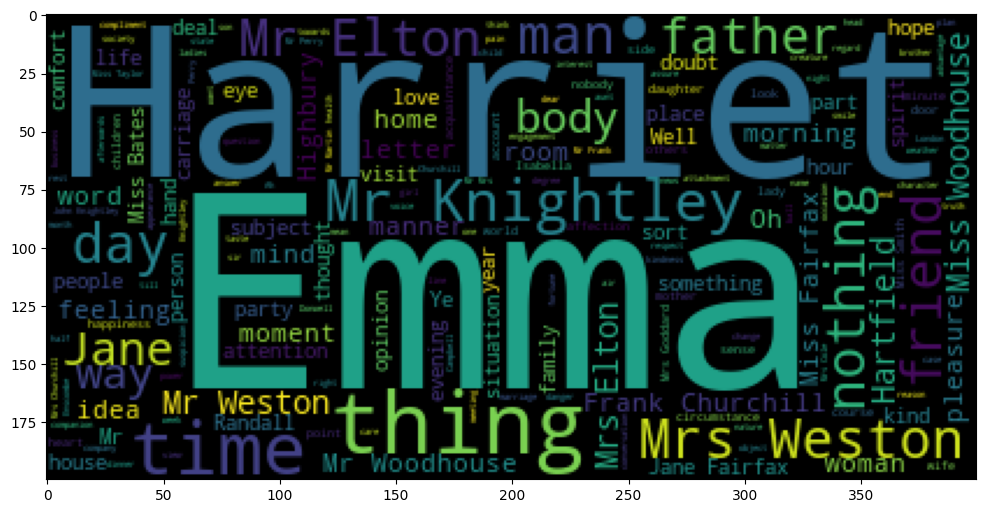

(0.0, 1.0, 0.0, 1.0)

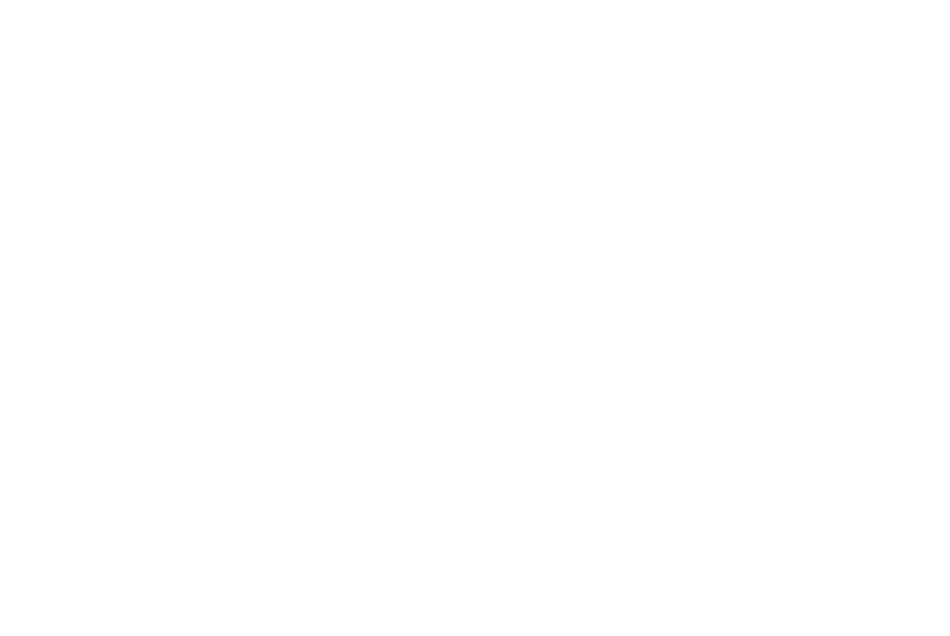

In [82]:
wordcloud=WordCloud()
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.show()
plt.rcParams['figure.figsize'] = [12,8] #기본값 [6.4, 4.8]
plt.axis('off')

컬러맵 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

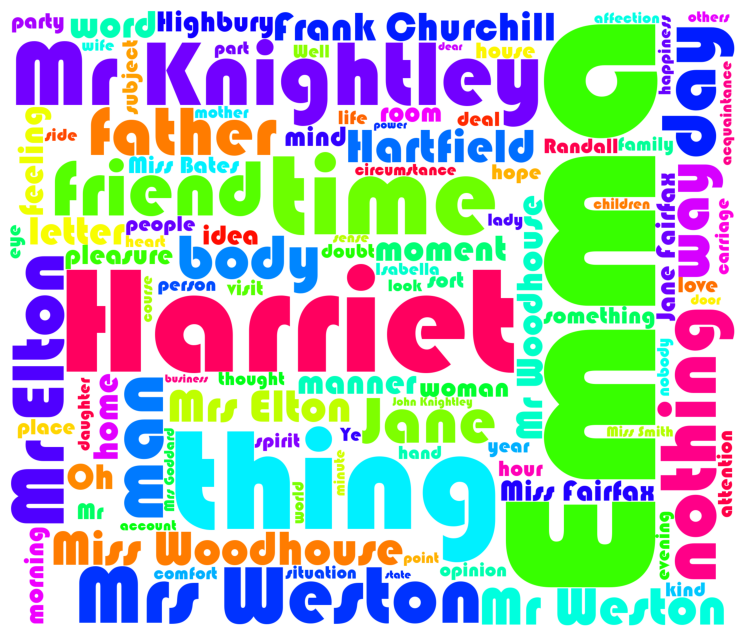

In [103]:
wordcloud = WordCloud(font_path='C:/Windows/Fonts/BAUHS93.TTF', #글자폰트
                       width=2000, #생성될 이미지 가로(픽셀) 기본값은 400
                       height=1700, #생성될 이미지 세로(픽셀) 기본값은 200
                       background_color='white', #배경색
                       max_words=100, #표시될 단어의 최대 갯수
                       relative_scaling=0.7, # 단어 빈도에 따른 크기 차이
                       colormap='hsv', # 글씨 색상들(컬러맵)
#                        max_font_size=3500,
#                        min_font_size=1
                     )
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()


In [104]:
#생성된 wordcloud 저장
wordcloud.to_file('emma2.jpg') #jpg나 png

In [111]:
#한글 말뭉치 kolaw_data
from mecab import MeCab
from nltk import FreqDist
import pandas as pd
analyzer = MeCab()
#noun_list= analyzer.nouns(kolaw_data)
noun_list= [word for word,tag in analyzer.pos(kolaw_data) if tag in ('NNG', 'NNP')]
noun_list[:10]
noun_wordcount = FreqDist(noun_list)

#최빈단어 10개 보기위해 시리즈로 변환
wordCnt = pd.Series(noun_wordcount)
wordCnt.sort_values(ascending=False, inplace=True)
wordCnt.head(10)

법률     121
대통령     84
조       79
국가      73
헌법      69
국민      69
국회      69
때       55
필요      31
위원      30
dtype: int64

In [127]:
#워드 클라우드에서 필요한 text
data_noun= ' '.join(noun_list[:300])

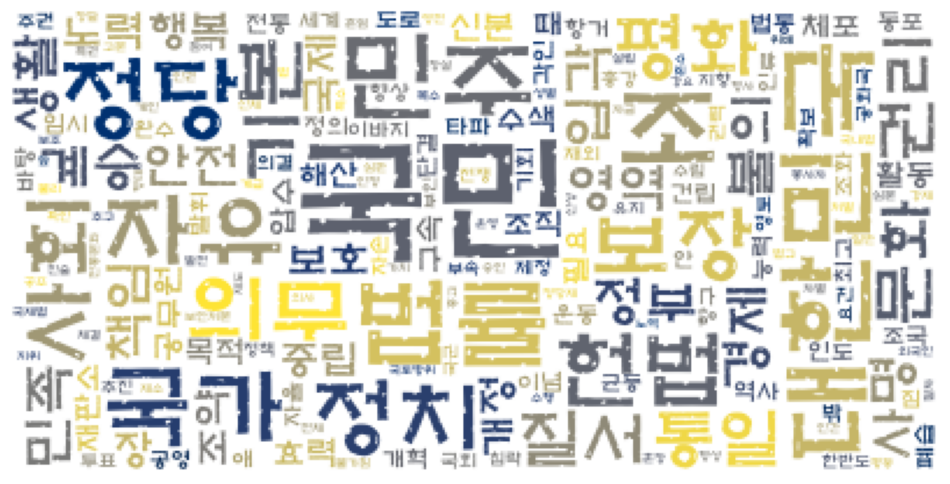

In [128]:
wordcloud = WordCloud(
                font_path='C:/Windows/Fonts/H2MKPB.TTF',
                background_color='white',
                max_words=400,
                colormap='cividis')
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [138]:
#불용어 처리
from wordcloud import STOPWORDS #영어권 등록된 불용어 셋
from nltk.corpus import stopwords 
print('라이브러리에 등록된 불용어 언어들:',stopwords.fileids())
불용어 = {'조', '대통령', '법률'}
print(불용어)

라이브러리에 등록된 불용어 언어들: ['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish', 'uzbek']
{'조', '법률', '대통령'}


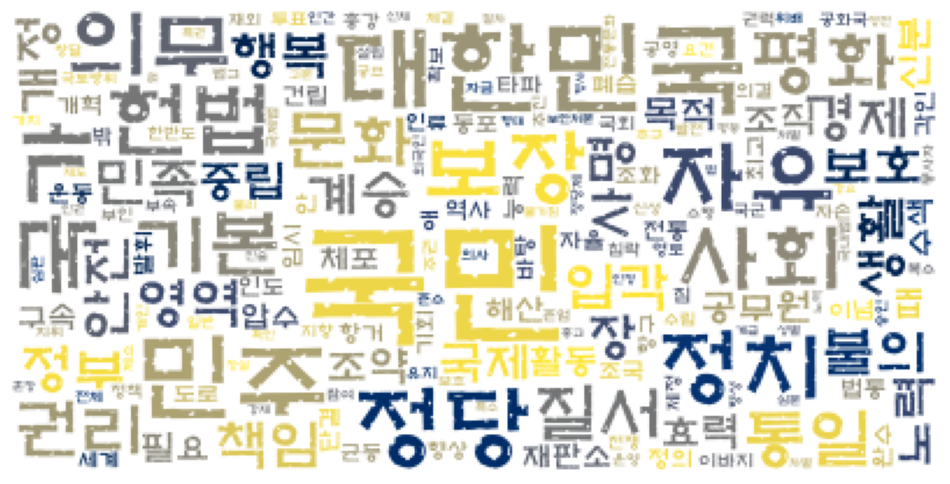

In [142]:
wordcloud = WordCloud(
                font_path='C:/Windows/Fonts/H2MKPB.TTF',
                background_color='white',
                max_words=900,
                stopwords=불용어,
                colormap='cividis')
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(1600, 1600, 3) <class 'numpy.ndarray'>


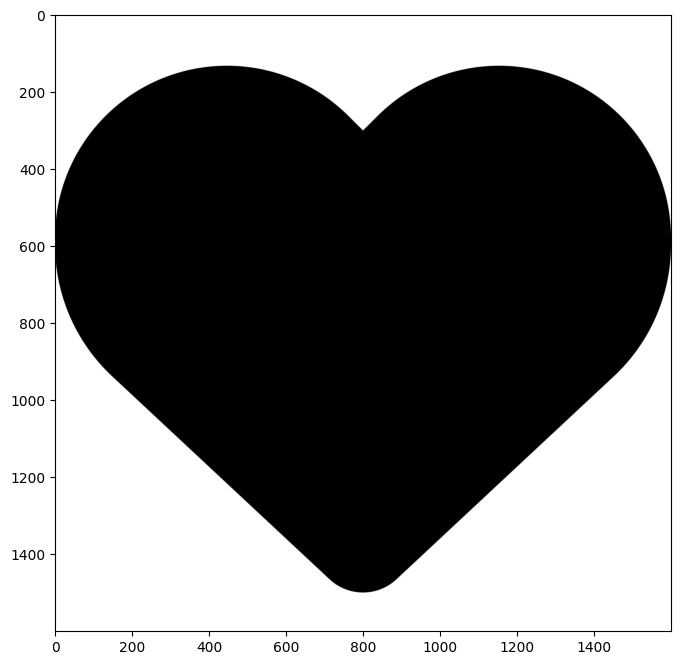

In [153]:
#워드클라우드의 mask가 될 이미지 -> numpy 배열
# 이미지를 넘파이 배열로 가져오기 방법1
import cv2
mask = cv2.imread('data/heart.jpg')
print(mask.shape,type(mask))
plt.imshow(mask)

<class 'PIL.JpegImagePlugin.JpegImageFile'> <class 'numpy.ndarray'> (1600, 1600)


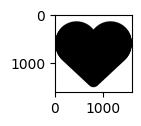

In [160]:
# 이미지를 넘파이 배열로 방법2
from PIL import Image
import numpy as np
img = Image.open('data/heart.jpg')
mask = np.array(img)
plt.figure(figsize=(1,1))
print(type(img),type(mask),mask.shape)
plt.imshow(mask, cmap='gray')

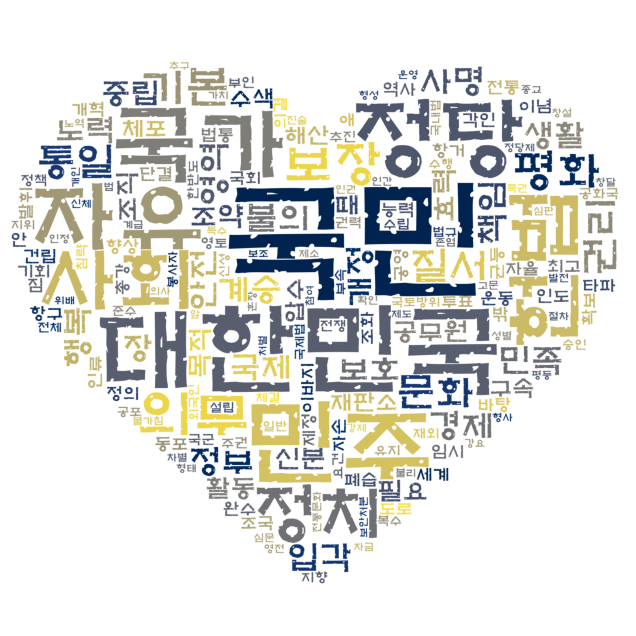

In [161]:
wordcloud = WordCloud(
                font_path='C:/Windows/Fonts/H2MKPB.TTF',
                background_color='white',
                max_words=900,
                stopwords=불용어,
                mask=mask,
                colormap='cividis')
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

numpy.ndarray

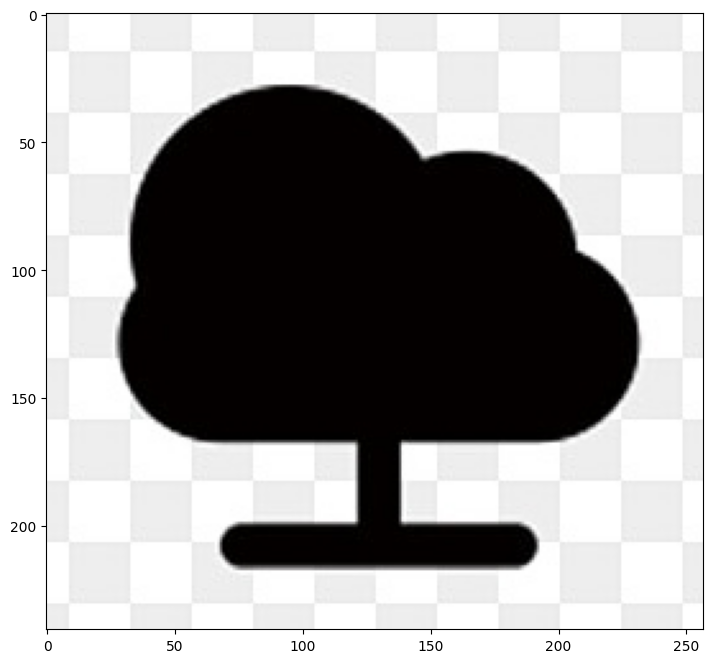

In [172]:
mask2=cv2.imread('data/test2.jpg')
plt.imshow(mask2)
#mask2.shape
img= Image.open('data/test2.jpg')
mask2=np.array(img) # 255:흰색 , 0:검정색
plt.imshow(mask2)
mask2 = np.where(mask2>200, 255, 0).astype(np.uint8) # 200보다 큰곳은 255로  아닌곳은 0으로 대체

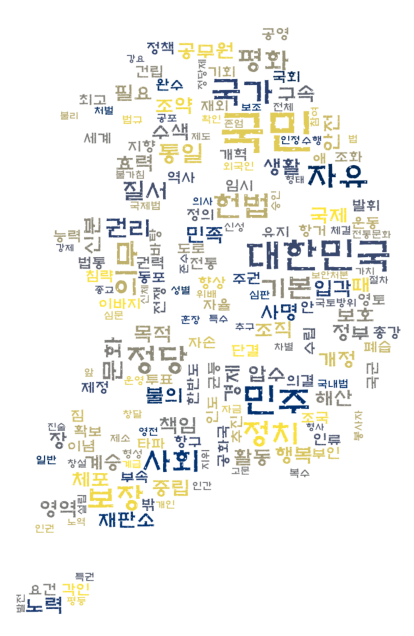

In [181]:
wordcloud = WordCloud(
                font_path='C:/Windows/Fonts/H2MKPB.TTF',
                background_color='white',
                max_words=900,
                stopwords=불용어,
                mask=mask2,
#                 contour_width=1,
#                 contour_color='green',
                colormap='cividis'
                )
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()
wordcloud.to_file('map.jpg') #jpg나 png

((1124, 720, 3), dtype('uint8'))

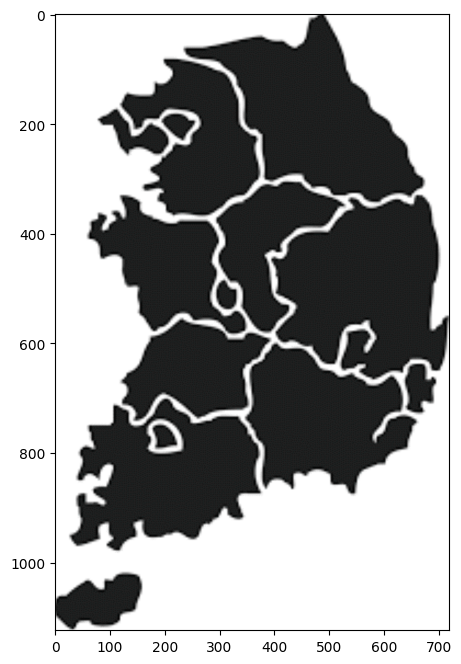

In [176]:
#1채널 이미지 -> 3채널 변환
img= Image.open('data/south_korea.png').convert('RGB')
mask2=np.array(img) # 255:흰색 , 0:검정색
plt.imshow(mask2)
mask2.shape, mask2.dtype

# 단어의 빈도수 시각화

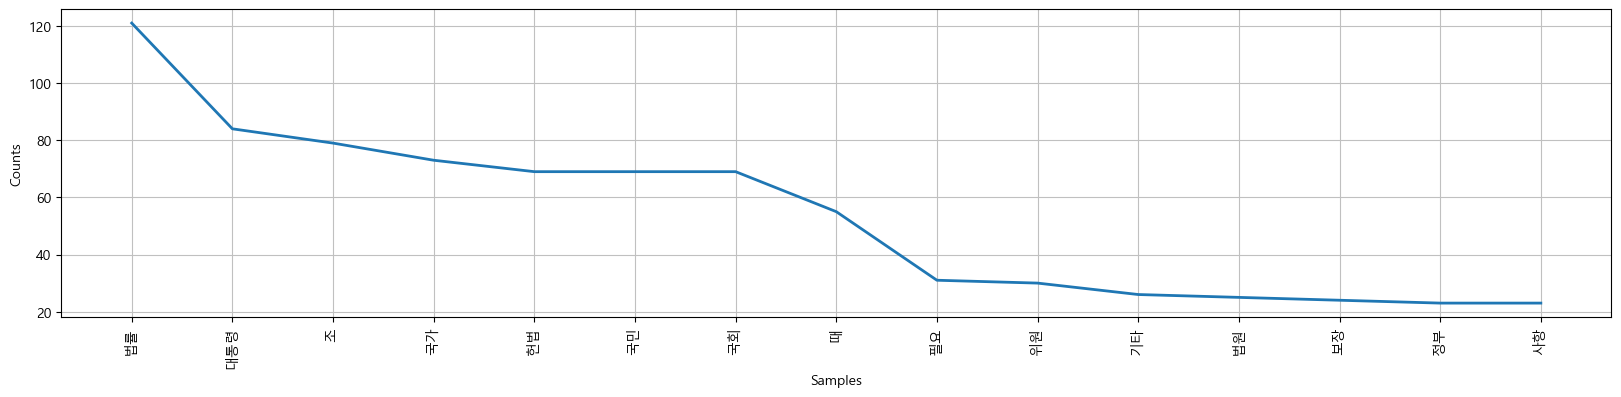

<Axes: xlabel='Samples', ylabel='Counts'>

In [185]:
from nltk import Text
plt.rcParams['font.family']='Malgun Gothic' 
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.figsize']=[20,4]
data_text= Text(noun_list)
data_text.plot(15)


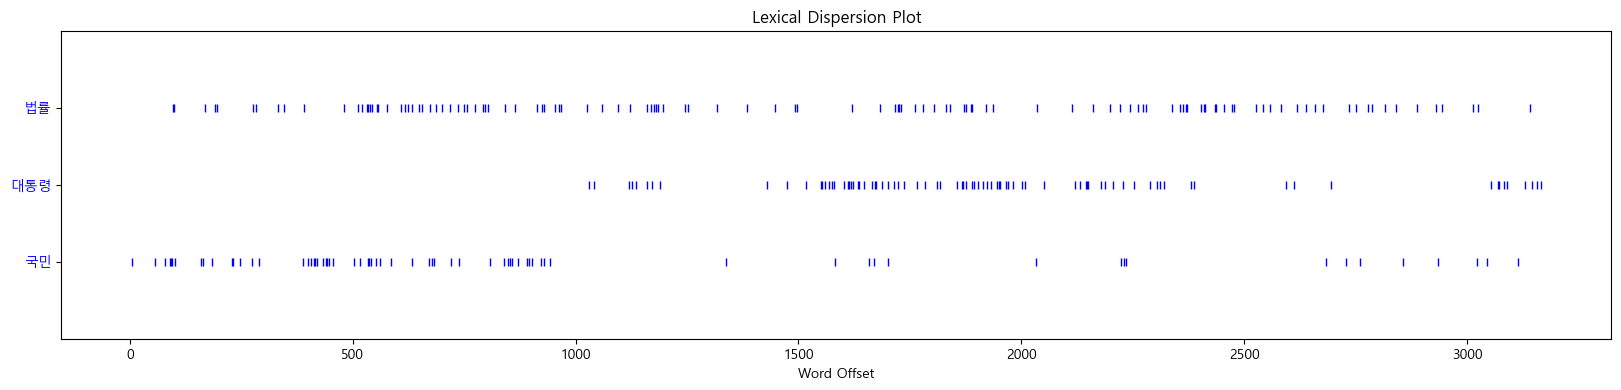

In [186]:
data_text.dispersion_plot(['법률', '대통령', '국민'])

# 6. 워드임베딩
- 단어간 벡터 계산 (단어간 거리계산)
- Word2vec은 주변 같이 나오는 단어는 의미가 유사하는 아이이더로 단어를 숫자 좌표로 바꿔서 계산

- 경제 20개를 각각 명사마 가져와서 list(naver API) -> 워드 임베딩(단어간 거리계산)

``` 
    [['단어1','단어2','단어3',......],
     ['단어4','단어5','단어6',......],
     ['단어1','단어7','단어2',......]...]
```

In [189]:
# .env 가져오기(방법1) - 강추
from dotenv import load_dotenv
import os
load_dotenv()
# print(os.getenv('Client_ID'))
# print(os.getenv('Client_Secret'))

True

In [190]:
# .env 가져오기(방법2) - 주퍼터환경에서 안될 수 있음
from decouple import config
# print(os.getenv('Client_ID'))
# print(os.getenv('Client_Secret'))

In [195]:
#방법1
import os
import requests 
import json
import pandas as pd
from dotenv import load_dotenv
load_dotenv() #환경 변수 load
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

url = f"https://openapi.naver.com/v1/search/news.json" # JSON 결과

params = {'query':'경제',
          'display':20, #가져올 데이터 갯수(기본값은 10)
          'sort':'date'# 최신순 뉴스
         } 

headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}
response =requests.get(url,params=params, headers=headers)

# print('response 상태: ',response.status_code)
# print(response.text[:30])
#data = json.loads(response_body) # 문자를 json형태로 변환
items=response.json()['items']#json
#제목(title)+' '+요약(description) 텍스트만 추출하여 list

news_texts=[]
for item in items:
    title =item.get('title').replace('<b>',' ').replace('</b>',' ')
    description = item.get('description').replace('<b>',' ').replace('</b>',' ')
    news_texts.append(title+' '+description)
news_texts[:3], len(news_texts)


(['폭스바겐코리아, 사고수리 품질보장 도입…출고 후 2년 보장  경제 적 부담을 낮추기 위한 지원도 마련했다. 사고수리 비용이 300만원 이상인 고객에게는 1년간 자기부담금 지원 프로그램을 제공한다. 전기차는 별도의 안전 점검이 이뤄진다. 수리 견적이 200만원을 넘는 전기차가... ',
  '[카드뉴스로 읽는 오늘의 운세] 9월 4일(금요일) 춘강 구박사가 알려주... 54년생 가정  경제 가 회복될 것이라. 66년생 지금은 너무 서두르면 손해니 천천히 행하라. 78년생 큰 염려 말라, 느긋해 지라, 담대해 지라. 90년생 마음대로 해도 이루게 되리라. 02년생 이성으로 인한 경사가 있으리라.... ',
  '경북도의회, 석면 제거·원전 감시체계 촉구…경북농협은 수해복구 ‘구... ◇연규식 도의원 “지역아동센터 석면 제거 서둘러야&quot;…긴급 예산 편성 촉구 경북=에너지 경제 신문 정재우... ◇김재준 도의원 “원전 절반 몰린 경북, 자체 안전감시 체계 갖춰야&quot; 경북=에너지 경제 신문 정재우 기자... '],
 20)

In [203]:
#명사추출(news_texts)
from konlpy.tag import Hannanum,Kkma, Komoran, Okt
from mecab import MeCab
analyzer =MeCab()
news = []
for article in news_texts:
    noun_list=analyzer.nouns(article)
    noun_list= [word for word, tag in analyzer.pos(article) if tag in ('NNG', 'NNP')]    
    news.append(noun_list)
print(news[:3])


[['폭스바겐', '코리아', '사고', '수리', '품질', '보장', '도입', '출고', '후', '보장', '경제', '부담', '지원', '마련', '사고', '수리', '비용', '이상', '고객', '간', '부담금', '지원', '프로그램', '제공', '전기차', '별도', '안전', '점검', '수리', '견적', '전기차'], ['카드', '뉴스', '오늘', '운세', '금요일', '춘강', '박사', '가정', '경제', '회복', '손해', '염려', '담대', '이성', '경사'], ['경북', '의회', '석면', '제거', '원전', '감시', '체계', '촉구', '경북', '농협', '수해', '복구', '규식', '도', '의원', '지역', '아동', '센터', '석면', '제거', '긴급', '예산', '편성', '촉구', '경북', '에너지', '경제', '신문', '정재우', '김재준', '도', '의원', '원전', '절반', '경북', '자체', '안전', '감시', '체계', '경북', '에너지', '경제', '신문', '정재우', '기자']]


In [206]:
print([len(nouns) for nouns in news])

[31, 15, 45, 33, 29, 32, 30, 35, 24, 26, 37, 41, 29, 31, 35, 36, 25, 29, 23, 40]


In [207]:
#워드 임베딩(단어간 거리 계산)
from gensim.models import Word2Vec
model =Word2Vec(news, #2차원 학습데이터
                window=15, # 각 단어의 좌우 15개 단어르 학습 컨텐츠로 사용
                min_count=2, #2회 이상 등장한 단어만 학습
                workers=-1, # 병렬처리 core갯수 (-1:모든 가용 core 다 사용)
                sg=1 #소량 데이터에서의 학습방식 / 대량 데이터에서는 0 
               )

In [208]:
# 학습한 단어 리스트
print(model.wv.index_to_key)

['경제', '지역', '지원', '시즌', '정부', '금융', '경북', '이전', '광양만', '활성', '정치', '의원', '통합', '포럼', '미국', '도심형', '장관', '부', '국제', '기술', '이번', '에너지', '원전', '의회', '안전', '수리', '다양', '사회', '워즈', '월드', '부산', '학', '정치학', '자유', '투자', '외국인', '여수', '제도', '민주당', '기획', '동', '유주', '취지', '생활임금', '서울시', '내용', '황', '젠슨', '규제', '글로벌', '정책', '국가', '서울', '기후', '공기', '제시', '포집', '텍', '카본', '미래', '한국', '위원회', '관계자', '슬로바키아', '현대모비스', '집행', '효과', '중요', '지표', '추석', '확대', '실효', '기관', '대표', '발전', '협약', '상생', '규모', '지속', '기업', '도움', '활용', '물품', '확산', '문화', '사이', '분쟁', '소송', '파양', '회장', '효율', '추진', '자금', '배우자', '문제', '역사', '기자', '정재우', '신문', '편성', '예산', '도', '촉구', '체계', '감시', '제거', '석면', '회복', '전기차', '제공', '고객', '비용', '부담', '보장', '사고']


In [ ]:
# 유사도가 높은 단어(거리가 가까운 단어) 10개(topn)
model.wv.most_similar('미국',topn=10)

In [216]:
#단어를 입력받아 유사한 단어 5개 출력하기
word= input('유사도를 알고싶은 단어는?')
if word in model.wv:
    print(model.wv.most_similar(word,topn=5))
else:
    print(f'{word} 단어가 훈련 데이터에 없습니다')

유사도를 알고싶은 단어는?학원
학원 단어가 훈련 데이터에 없습니다
